<center>
    <h1></h1>
    <h1><b>OCES 5303</b></h1>
    <h2>Assignment 2</h2>
    <hr>
    <p>Jonas Mathisrud Sterud</p>
    <p>21335836</p>
</center>

<center>
    <h1></h1>
    <h3><i>Abstract</i></h3>
    <p>
    Abstrac here.
    <small style="margin-left: 1em">[1]</small>
    </p>
    <p>
    In this assignment, we will explore the dataset, and perform ...
    </p>
    <img src="./figures/cover.jpg" width="50%">
</center>

<h1>The Data</h1>

<p>
The dataset which we'll look at in this assignment, has been supplied by Charmaine Yung <sup><small>[1]</small></sup>, from one of the papers <sup><small>[2]</small></sup> she contributed to.
</p>

<p>
It's data collected at ... using ...,
</p>

<p>
We'll explore the dataset, and create a neural network model that'll hopefully tell us a bit more about how the abundance of bacteria is affected by the temperature, seasons, etc.
</p>

In [2]:
#! This is code from the previous assignment.

#####################################
#       You might need to restart   #
#           the kernel after        #
#           running this cell.      #
#####################################

## Detect environment

try:
    import google.colab # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

## Clone repository and download dependencies
## (assumes using Conda if not in Google Colab)

if IN_COLAB:
    None
    !git clone https://github.com/jonassterud/OCES5303_A2.git
    !cp -r OCES5303_A2/* .
    %pip install -q -r ./requirements.txt
else:
    None
    %conda install -c conda-forge -c pytorch -qq --file ./requirements.txt

Channels:
 - conda-forge
 - pytorch
 - defaults
Platform: linux-64
Solving environment: ...working... done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [46]:
## Imports

import numpy as np
import pandas as pd
import plotly.io as pio
import plotly.express as px
import matplotlib.pyplot as plt
import torch
import os

from plotly.subplots import make_subplots
from sklearn import set_config
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer, OneHotEncoder, PolynomialFeatures, SplineTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, PredictionErrorDisplay
from sklearn.cluster import KMeans
from torch import nn
from skorch import NeuralNetRegressor

## Configuration

# set_config(transform_output = "pandas")
pio.templates.default = "plotly_dark"
seed = int(9000 + 0.0001)
_ = torch.manual_seed(seed)

<h1>Parsing</h1>

<p>
The dataset, which contains 151 samples, has the following variables:
</p>

<ul>
    <li><code>YearDay</code>: Day of the year</li>
    <li><code>Bacteria_abundance</code>: Number of bacteria cells</li>
    <li><code>Projected_Daily_Insolation</code>: Solar heating</li>
    <li><code>Temp</code>: Sea Temperature (℃)</li>
    <li><code>MLLW</code>: Low of the tide TODO?</li>
    <li><code>Salinity</code>: Practical Salinity (PSU)</li>
    <li><code>Oxygen_Saturation</code>: ...</li>
    <li><code>pH</code>: pH level.</li>
    <li><code>DIC</code>: ...</li>
    <li><code>Chlorophyll</code>: ...</li>
    <li><code>NH4</code>: ...</li>
    <li><code>NO2.NO3</code>: ...</li>
    <li><code>PO4</code>: ...</li>
    <li><code>SiO4</code>: ...</li>
    
</ul>

<p>
We load the data from a <code>.txt</code> file into a Pandas <code>DataFrame</code>.
Here, we'll also drop the <code>SampleID</code> variable, since this is just an identifier for the sample, and won't be any useful for our model.
</p>

<p>
Additionaly, we see that the values of <code>YearDay</code> is linear. In reality, years are, of course, cyclical. We'll handle this later.
</p>

In [47]:
df = pd.read_csv("./data/PIDweekly_env_data.txt", sep=r"\s+")
df["YearDay"] = df["YearDay"].astype(float) 
df = df.drop(columns=["SampleID"])

<h1>Split Data</h1>

<p>
First, we'll split the data up into two disjoint subsets: train and test.
</p>

<p>
We'll use the training set for explorative data analysis and training our neural network models.
</p>

<p>
To avoid overfitting (i.e. not being able to generalize), we'll use cross validation to get an unbiased performance. +++
</p>

<p>
Finally, to get a totally unbiased performance metric of our final model, we'll check the generalization error on our test set.
</p>

In [48]:
## Split data (85%, 15%)

X = df.drop(columns = ["Bacteria_abundance"])
y = df["Bacteria_abundance"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.85, random_state = seed)

## Combined train set (for visualization)

Xy_train = pd.concat([X_train, y_train], axis=1)

# Use periodic spline features:
# https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html#periodic-spline-features

<h1>Exploratory Data Analysis</h1>

<p>
...
</p>

<h1>Cyclic Features</h1>

<p>
As previously mentioned, we're dealing with some cyclic data.
We have the <code>YearDay</code> variable, which tells us which day of the year the observation happened. The values here are linear, so in order to make them cyclic, we have to transform them.
</p>

<p>
Now, there's a variety of transformation methods for this, but here we'll use a periodic spline transformer. <sup><small>[3]</small></sup>
</p>

In [94]:
## Create spline transformer

_t_cyclic_spline = SplineTransformer(
    degree=365,
    n_knots=365 + 1, # Include bias term (+ 1)
    knots=np.linspace(0, 365, 365 + 1).reshape(365 + 1, 1),
    extrapolation="periodic",
    include_bias=True,
)

t_cyclic_spline = ColumnTransformer(
    [("cyclic", _t_cyclic_spline, ["YearDay"])],
    remainder="passthrough",
    verbose_feature_names_out=False
)

In [173]:
Xy_train

,YearDay,Projected_Daily_Insolation,Temp,MLLW,Salinity,Oxygen_Saturation,pH,DIC,Chlorophyll,NH4,NO2.NO3,PO4,SiO4,Bacteria_abundance
109,802.0,344.95,12.8,1.13,30.79,92.60,7.86,2001.00,1.53,109.50,0.04,0.08,3.54,2694117.647
137,998.0,347.08,23.3,0.89,34.22,96.45,7.96,2081.20,5.74,51.00,0.00,0.02,7.25,4226865.672
127,928.0,470.81,29.4,0.19,34.54,91.70,7.97,2057.33,6.73,28.50,0.00,0.05,7.14,4104878.049
123,900.0,483.33,25.6,0.00,34.14,90.40,7.92,2075.43,5.26,130.50,0.03,0.10,2.92,2565000.000
108,795.0,326.64,10.9,0.11,28.34,92.00,7.87,1908.03,2.88,39.00,0.00,0.05,5.74,3677922.078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,89.0,385.59,11.8,0.22,30.00,100.90,7.88,1956.47,5.21,240.85,0.00,0.03,3.00,3600000.000
95,705.0,200.93,14.3,0.85,31.29,104.60,7.94,1989.40,3.45,13.00,0.00,0.05,5.05,1707692.308
87,649.0,308.82,21.5,0.30,30.00,90.40,7.91,2024.20,11.64,204.50,0.00,0.10,11.20,2427450.980
19,166.0,483.07,26.4,0.61,36.00,100.70,8.06,2177.76,3.13,181.56,0.00,0.12,2.99,5278378.378


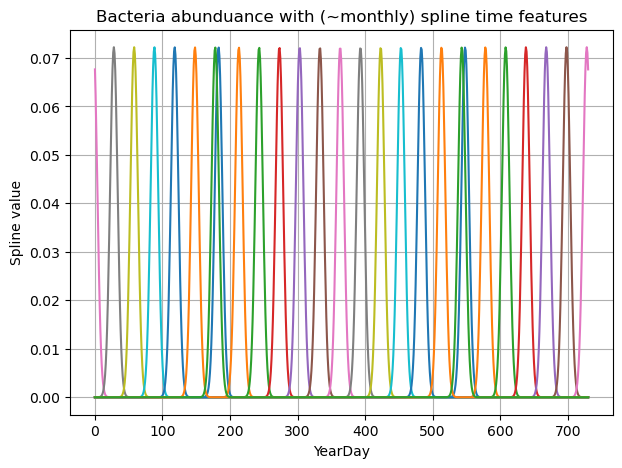

In [ ]:
df_time = pd.DataFrame(
    np.linspace(0, 365 * 2, 365 * 2).reshape(-1, 1),
    columns=["YearDay"],
)

df_cyclic_features = t_cyclic_spline.set_output(transform="pandas").fit_transform(df_time)
df_cyclic_features["YearDay"] = df_time["YearDay"]

plt.figure(figsize=(7, 5))
for i in range(0, 365, 30):
    plt.plot(df_cyclic_features["YearDay"], df_cyclic_features[f"YearDay_sp_{i}"])
plt.xlabel("YearDay")
plt.ylabel("Spline value")
plt.title(f"Bacteria abunduance with (monthly) spline time features")
plt.grid()
plt.show()

In [98]:
## Create trigonmetric transformer

_t_cyclic_sin = FunctionTransformer(lambda x: np.sin(x / 365 * 2 * np.pi))
_t_cyclic_cos = FunctionTransformer(lambda x: np.cos(x / 365 * 2 * np.pi))

t_cyclic_trig = ColumnTransformer(
    [("cyclic_sin", _t_cyclic_sin, ["YearDay"]), ("cyclic_cos", _t_cyclic_cos, ["YearDay"])],
    remainder="passthrough",
    verbose_feature_names_out=True
)

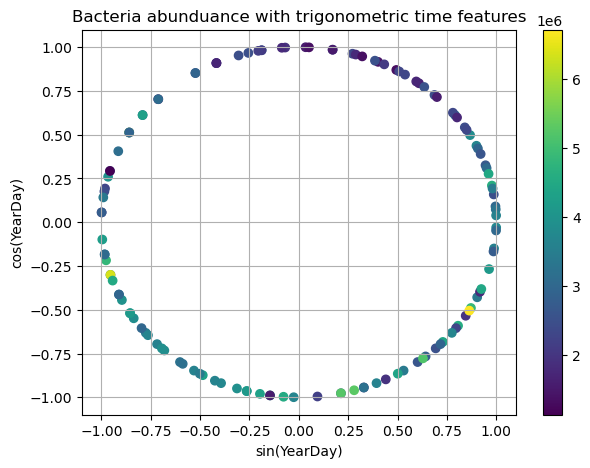

In [152]:
df_cyclic_features = t_cyclic_trig.set_output(transform="pandas").fit_transform(Xy_train)

plt.subplots(figsize=(7, 5))
plt.scatter(df_cyclic_features["cyclic_sin__YearDay"], df_cyclic_features["cyclic_cos__YearDay"], c=df_cyclic_features["remainder__Bacteria_abundance"])
plt.xlabel("sin(YearDay)")
plt.ylabel("cos(YearDay)")
plt.title(f"Bacteria abunduance with trigonometric time features")
plt.colorbar()
plt.grid()
plt.show()

<h1>Feature Selection</h1>

<p>
...
</p>

In [50]:
# Filter features transformer
features = [
    "Projected_Daily_Insolation",
    "Temp",
    "MLLW",
    "Salinity",
    "Oxygen_Saturation",
    "pH",
    "DIC",
    "Chlorophyll",
    "NH4",
    "NO2.NO3",
    "PO4",
    "SiO4",
]

t_drop = ColumnTransformer(
    [("drop", "drop", features)],
    remainder = "passthrough",
    verbose_feature_names_out = False,
)

<h1>Tensors</h1>

<p>
Now, let's create a transformer that can turn our <code>DataFrame</code> into something more suitable for Pytorch - tensors.
</p>

In [51]:
## Transformation

def _add_tensors(data):
    data_c = data.copy()
    data_c = torch.from_numpy(np.array(data_c)).type(torch.float32)

    return data_c

t_tensors = FunctionTransformer(func=_add_tensors)

# ## Transformation for y

# def _add_tensors_y(data):
#     data_c = data.copy()
#     data_c = torch.from_numpy(np.array(data_c)).type(torch.float32).view(-1, 1)

#     return data_c

# def _inverse_add_tensors_y(data):
#     data_c = data.copy()
#     data_c = pd.DataFrame(data_c)

#     return data_c

# t_tensors_y = TransformedTargetRegressor(func=_add_tensors_y, inverse_func=_inverse_add_tensors_y)

<h1>Neural Network</h1>

<p>
Now, let's create our neural network model.
</p>

In [90]:
class Layer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.linear_ab = nn.Linear(in_features, out_features)
        self.linear_bb = nn.Linear(out_features, out_features)
        self.activate = nn.ReLU()

    def forward(self, x):
        out = self.linear_ab(x)
        out = self.activate(out)

        return out


class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()

        self.f = 64

        self.b1 = Layer(365 + 12, self.f)
        self.b2 = Layer(self.f, self.f // 2)
        self.b3 = Layer(self.f // 2, self.f // 4)
        self.final = nn.Linear(self.f // 4, 1)

    def forward(self, x):
        out = self.b1(x)
        out = self.b2(out)
        out = self.b3(out)
        out = self.final(out)

        return out

r_nn = NeuralNetRegressor(
    NeuralNetwork,
    max_epochs=100,
    lr=0.1,
    # Shuffle training data on each epoch
    iterator_train__shuffle=True,
    #verbose=0,
)

In [78]:
class RecurrentNeuralNetwork(nn.Module):
    def __init__(self):
        super(RecurrentNeuralNetwork, self).__init__()

        self.rnn = nn.RNN(365 + 12, 4, num_layers=1, nonlinearity="relu")
        self.decoder = nn.Linear(4, 1)

    def forward(self, x):
        x = x.unsqueeze(0) # add seq_len

        out, hidden = self.rnn(x)
        out = self.decoder(out[-1, :])

        return out
    
r_rnn = NeuralNetRegressor(
    RecurrentNeuralNetwork,
    max_epochs=100,
    lr=0.1,
    iterator_train__shuffle=True,
)

<h1>Metrics</h1>

<p>
...
</p>

In [54]:
class Metrics:
    def __init__(self, model, X, y):
        self.keys = [
            ("Mean Absolute Error", "neg_mean_absolute_error"),
            ("Root Mean Squared Error", "neg_root_mean_squared_error"),
            ("R2", "r2"),
        ]

        self.metrics = list(map(lambda kv: (
            kv[0],
            np.mean(cross_val_score(model, X, y, scoring=kv[1]
        ))), self.keys))

    def __repr__(self):
        return '\n'.join(map(lambda kv: f"{kv[0]}: {np.abs(kv[1]):.5f}", self.metrics))

<h1>Pipeline</h1>

<p>
...
</p>

In [87]:
pipeline = Pipeline([
    # ("drop", t_drop.set_output(transform="pandas")),
    ("cyclic", t_cyclic.set_output(transform="pandas")),
    ("scale", StandardScaler()),
    ("tensors", t_tensors), # Need to call explicitly for y
    ("regression", TransformedTargetRegressor(regressor=r_nn, transformer=StandardScaler())),
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cyclic', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cyclic', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

In [88]:
pipeline = pipeline.fit(X_train, t_tensors.transform(y_train).view(-1, 1))
print(Metrics(pipeline, X_train, t_tensors.transform(y_train).view(-1, 1)))

  epoch    train_loss    valid_loss     dur
-------  ------------  ------------  ------
      1        1.1122        0.7570  0.0089
      2        1.0607        0.7532  0.0104
      3        1.0367        0.7523  0.0116
      4        1.0200        0.7521  0.0137
      5        1.0046        0.7517  0.0111
      6        0.9887        0.7513  0.0127
      7        0.9708        0.7508  0.0123
      8        0.9497        0.7505  0.0118
      9        0.9240        0.7510  0.0159
     10        0.8932        0.7531  0.0160
     11        0.8564        0.7585  0.0126
     12        0.8122        0.7697  0.0148
     13        0.7605        0.7906  0.0130
     14        0.7016        0.8224  0.0096
     15        0.6396        0.8718  0.0124
     16        0.5766        0.9335  0.0176
     17        0.5163        1.0066  0.0155
     18        0.4627        1.0777  0.0140
     19        0.4141        1.1542  0.0114
     20        0.3744        1.2265  0.0166
     21        0.3421        1.2

<h1>Visualize predictions</h1>

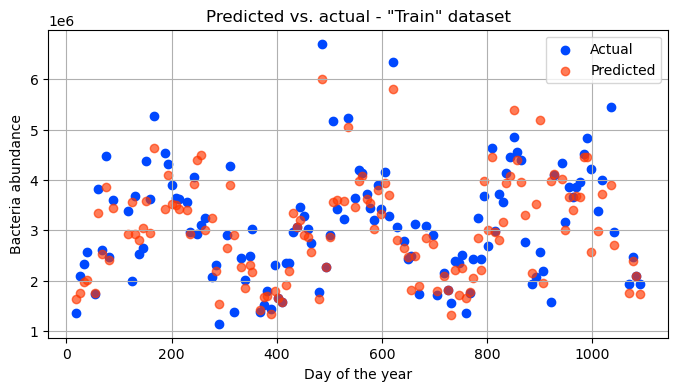

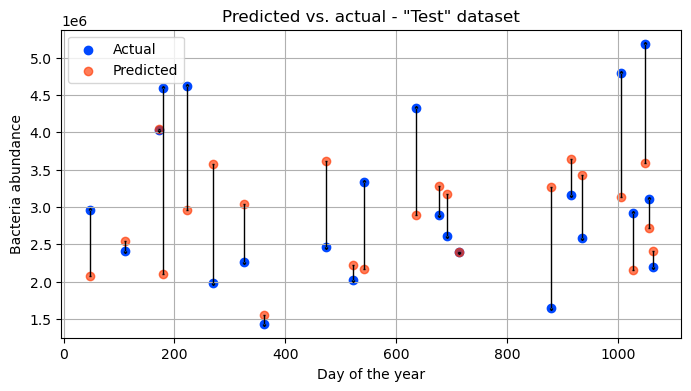

In [91]:
for (name, X, y) in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
    results_df = X.copy()
    results_df["target_actual"] = y.copy()
    results_df["target_predicted"] = pipeline.predict(X)
    results_df["target_error"] = results_df["target_actual"] - results_df["target_predicted"]
    results_df["uplims"] = list(map(lambda v: int(v < 0), results_df["target_error"]))
    results_df["lolims"] = list(map(lambda v: int(v > 0), results_df["target_error"]))
    results_df["target_error_scaled"] = list(map(lambda v: np.abs(v), results_df["target_error"]))
    results_df = results_df.sort_values(by="YearDay")

    plt.figure(figsize=(8, 4))
    plt.scatter(results_df["YearDay"], results_df["target_actual"], color="#0048FF", label="Actual")
    plt.scatter(results_df["YearDay"], results_df["target_predicted"], color="#FF3700A7", label="Predicted")
    
    if (name == "Test"):
        plt.errorbar(
            results_df["YearDay"], results_df["target_predicted"],
            yerr=results_df["target_error_scaled"],
            uplims=results_df["uplims"],
            lolims=results_df["lolims"],
            fmt=" ",
            ecolor="black",
            capsize=1,
            elinewidth=1
        )
    
    plt.xlabel("Day of the year")
    plt.ylabel("Bacteria abundance")
    plt.legend()
    plt.title(f"Predicted vs. actual - \"{name}\" dataset")
    plt.grid()
    plt.show()

<h1>References</h1>

<p>[1] Yung Lab. (2026). <a href="https://www.charmaineyung.com/" target="_blank">https://www.charmaineyung.com/</a> (Accessed online: 30.03.2026)</p>
<p>[2] Ward, C., Yung, CM., Davis, K. et al. Annual community patterns are driven by seasonal switching between closely related marine bacteria. ISME J 11, 1412–1422 (2017). <a href="https://doi.org/10.1038/ismej.2017.4" target="_blank">https://doi.org/10.1038/ismej.2017.4</a> (Accessed online: 30.03.2026)</p>
<p>[3] scikit-learn developers. (2026). <a href="https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html" target="_blank">https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html</a> (Accessed online: 30.03.2026)</p>